# Joint discourse x semantic analysis - JUSTIFICATION level (RQ2)

**This replaces the earlier sentence-level joint analysis**, which was
withdrawn on 2026-08-27 and whose notebook, tables, figures and qualitative
sample have been deleted. Recover them from git history if ever needed.

### Why the unit changed

Same-sentence co-occurrence was the wrong definition of association:

* an explicit connective can relate content across a sentence boundary -
  *"He swapped Paul with Mike. Therefore Mike is the Werewolf."* carries
  Mechanical in sentence 1 and Contingency in sentence 2, and both plainly
  belong to the same short argument;
* it is a **cross-model confound**. A model that packs a thought into one
  sentence scored a co-occurrence; a model that split the same thought over
  two did not. These three models differ systematically in justification
  length (3.16 / 3.89 / 3.48 sentences), so the sentence-level metric was
  partly measuring packaging.

The unit is now the **justification**. Same-sentence co-presence is retained,
but demoted to a *localization diagnostic* (section 8) - reported, never
required.

### What is still not established

The parser identifies explicit connectives and their PDTB sense; it does not
recover discourse arguments. A justification containing both a category and a
relation is an association between the kind of information it carries and the
kind of explicit marking it uses. Widening the window from sentence to
justification makes that claim **weaker**, not stronger.

### Inherited design rules

Per run, then mean and SD across the three stochastic runs; greedy separate
with SD undefined; bootstraps resample games with all runs and justifications
attached, same ids across models; 10,000 replicates, seed 20260826,
percentile CIs, no p-values. Discourse density is the canonical
ratio-of-sums definition from the frozen discourse analysis, not a new one.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display


def find_repo_root(start=None, repo_name="masters_thesis_sdg"):
    current = (start or Path.cwd()).resolve()
    while current.name != repo_name:
        if current.parent == current:
            raise FileNotFoundError(f"repo root {repo_name!r} not found")
        current = current.parent
    return current


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.justification_analysis.joint import joint_final as jf
from src.justification_analysis.joint_justification import justification_joint as kj
from src.justification_analysis.joint_justification import justification_figures as kfig
from src.justification_analysis.joint_justification import justification_qualitative as kq

TABLES = REPO_ROOT / kj.FINAL_TABLES_SUBPATH
FIGURES = REPO_ROOT / kj.FINAL_FIGURES_SUBPATH
QUALITATIVE = REPO_ROOT / kj.QUALITATIVE_SUBPATH
for directory in (TABLES, FIGURES, QUALITATIVE):
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 220)

print("tables     :", TABLES.relative_to(REPO_ROOT))
print("figures    :", FIGURES.relative_to(REPO_ROOT))
print("qualitative:", QUALITATIVE.relative_to(REPO_ROOT))
print("low-support diagnostic flag at N(c) <", kj.LOW_SUPPORT_DIAGNOSTIC,
      "justifications per run (diagnostic, NOT a filter)")

tables     : analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic_justification\thesis_tables\final_joint_justification
figures    : analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic_justification\figures\final_joint_justification
qualitative: analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic_justification\qualitative
low-support diagnostic flag at N(c) < 30 justifications per run (diagnostic, NOT a filter)


## 2. Load both frozen layers and build the justification frame

The sentence-level records are the input and are kept underneath, so local
realizations remain inspectable.

In [2]:
layers = jf.load_layers(REPO_ROOT)
alignment = jf.align_relations(layers)
sentences_joint = jf.build_joint_sentences(layers, alignment)
metadata = kj.load_justification_metadata(REPO_ROOT)
justifications = kj.build_justification_frame(
    layers, alignment, sentences_joint, metadata)

print("sentences     :", sentences_joint.shape)
print("justifications:", justifications.shape)
print("words (WORD_PATTERN):", int(justifications["n_words"].sum()))
display(justifications.head(3)[
    ["model", "game_id", "run_label", "n_sentences", "n_words",
     "n_semantic_categories", "n_relations", "vote", "is_correct"]])

sentences     : (8044, 32)
justifications: (2292, 55)
words (WORD_PATTERN): 169748


,model,game_id,run_label,n_sentences,n_words,n_semantic_categories,n_relations,vote,is_correct
0,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,3,57,3,1,Hailey,False
1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,3,82,2,5,No Werewolf,False
2,Gemma 4 2B,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,run_1,2,64,3,2,Elliot,False


## 3. Validation

In [3]:
validation = kj.validation_report(layers, alignment, sentences_joint,
                                  justifications)
display(validation)
failures = validation.loc[validation["status"] == "FAIL"]
assert len(failures) == 0, f"validation failed:\n{failures}"
print(f"all {len(validation)} checks passed")

,check,observed,expected,status
0,justifications,2292,2292,OK
1,no duplicate justification records,0,0,OK
2,no justification lost,2292,2292,OK
3,underlying canonical sentences,8044,8044,OK
4,sentence counts sum to the corpus,8044,8044,OK
5,semantic labels unchanged,11526,11526,OK
6,accepted discourse relations,5504,5504,OK
7,relation counts aggregate without loss,5504,5504,OK
8,top-level counts aggregate without loss,"{'Comparison': 1608, 'Contingency': 1534, 'Exp...","{'Comparison': 1608, 'Contingency': 1534, 'Exp...",OK
9,top-level totals reproduce the frozen discours...,"{'Comparison': 1608, 'Contingency': 1534, 'Exp...","{'Comparison': 1608, 'Contingency': 1534, 'Exp...",OK


all 19 checks passed


### 3.1 The toy case this rewrite exists for

Sentence 1 carries Mechanical, sentence 2 carries Contingency, and they never
share a sentence. The justification-level analysis must record the pairing and
the localization rate must be 0. The deprecated analysis recorded nothing.

In [4]:
toy = kj.toy_example_check()
display(toy)
assert not (toy["status"] == "FAIL").any()
print("toy example behaves as required")

,check,observed,expected,status
0,category present anywhere in the justification,True,True,OK
1,relation present anywhere in the justification,True,True,OK
2,justification-level pairing IS recorded,True,True,OK
3,the pair never shares a sentence (localization...,False,False,OK
4,deprecated sentence-level analysis would have ...,True,True,OK


toy example behaves as required


## 4. Presence saturates - read this before any P(r|c)

At justification level almost every justification contains at least one
explicit relation, so `P(r|c)` is dominated by each model's overall discourse
profile rather than by the semantic category. This is the single most
important difference from the sentence-level analysis, and it is why lift and
density carry the interpretive weight here.

In [5]:
prevalence_runs = kj.conditional_prevalence(justifications, "top_level")
prevalence = kj.summarise_across_runs(
    prevalence_runs, "conditional_prevalence",
    {"mean_n_with_category": ("n_justifications_with_category", "mean"),
     "low_support_diagnostic": ("low_support_diagnostic", "any")})

any_relation = prevalence.loc[
    prevalence["discourse_relation"].astype(str).eq(kj.ANY_RELATION)
    & prevalence["decoding_group"].astype(str).eq("Stochastic")]
print("P(at least one explicit relation | category), %")
display((100 * any_relation.pivot_table(
    index="semantic_category", columns="model",
    values="mean_conditional_prevalence", observed=True)).round(1))

print("N(c): justifications carrying the category, per run")
display(any_relation.pivot_table(
    index="semantic_category", columns="model",
    values="mean_n_with_category", observed=True).round(0))

P(at least one explicit relation | category), %


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
semantic_category,,,
Mechanical,95.2,97.4,96.0
Testimony,96.7,97.0,95.9
SocialJudgment,97.0,94.1,94.5
Behavioral,94.7,94.6,96.9
ClaimComparison,100.0,96.9,97.6
Payoff,97.1,95.9,98.2
Uncertainty,97.4,96.4,93.5


N(c): justifications carrying the category, per run


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
semantic_category,,,
Mechanical,6.0,13.0,101.0
Testimony,102.0,144.0,188.0
SocialJudgment,113.0,107.0,57.0
Behavioral,32.0,111.0,118.0
ClaimComparison,15.0,35.0,109.0
Payoff,174.0,137.0,53.0
Uncertainty,114.0,81.0,21.0


## 5. Conditional prevalence P(r | c)

In [6]:
substantive = prevalence.loc[
    prevalence["discourse_relation"].astype(str).ne(kj.ANY_RELATION)]
for model in kj.MODEL_ORDER:
    print(f"{model} - P(r|c) %, stochastic mean")
    display((100 * kj.matrix(substantive, model, "Stochastic",
                             "mean_conditional_prevalence")).round(1))

Gemma 4 2B - P(r|c) %, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,54.4,84.1,59.9,19.4
Testimony,56.9,52.0,47.7,21.5
SocialJudgment,57.6,52.2,47.8,18.5
Behavioral,50.1,53.4,45.7,17.7
ClaimComparison,54.0,53.0,55.9,48.4
Payoff,59.9,60.5,47.8,14.8
Uncertainty,72.2,62.9,50.3,11.1


Gemma 4 4B - P(r|c) %, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,75.6,49.7,39.7,24.6
Testimony,81.9,34.2,46.1,31.0
SocialJudgment,77.9,23.2,47.6,28.5
Behavioral,79.3,25.3,42.1,31.5
ClaimComparison,68.1,22.4,49.1,59.9
Payoff,79.8,36.1,47.6,25.2
Uncertainty,89.1,32.7,42.7,16.7


Gemma 4 31B - P(r|c) %, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,34.3,72.9,56.1,38.6
Testimony,45.1,57.9,54.0,41.8
SocialJudgment,51.6,43.1,52.2,35.6
Behavioral,50.1,57.0,55.5,47.3
ClaimComparison,46.9,54.9,55.1,53.9
Payoff,47.6,76.3,58.8,37.2
Uncertainty,64.4,42.5,59.8,25.9


## 6. Conditional discourse density

Relations of class *r* per 100 words, **within justifications carrying
category c**. Definition reused verbatim from the frozen discourse analysis: a
ratio of sums per run. Compare each row against the model's own corpus-wide
density to see whether carrying the category shifts the discourse profile.

In [7]:
density_runs = kj.conditional_density(justifications, "top_level")
density = kj.summarise_across_runs(
    density_runs, "relations_per_100_words",
    {"mean_per_justification_density": ("mean_per_justification_density", "mean"),
     "low_support_diagnostic": ("low_support_diagnostic", "any")})
density_substantive = density.loc[
    density["discourse_relation"].astype(str).ne(kj.ANY_RELATION)]

for model in kj.MODEL_ORDER:
    print(f"{model} - relations per 100 words within justifications carrying c")
    display(kj.matrix(density_substantive, model, "Stochastic",
                      "mean_relations_per_100_words").round(2))

print("frozen corpus-wide reference (all justifications, from the discourse strand):")
display(pd.DataFrame(
    {"Comparison": [0.94, 1.20, 0.69], "Contingency": [1.14, 0.51, 1.07],
     "Expansion": [0.97, 0.65, 1.02], "Temporal": [0.27, 0.44, 0.76]},
    index=kj.MODEL_ORDER))

Gemma 4 2B - relations per 100 words within justifications carrying c


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.89,1.56,1.30,0.29
Testimony,0.94,0.96,0.90,0.38
SocialJudgment,0.93,0.97,0.98,0.31
Behavioral,0.76,0.95,0.80,0.30
ClaimComparison,0.93,0.89,0.99,0.79
Payoff,0.97,1.16,0.96,0.25
Uncertainty,1.14,1.19,0.96,0.18


Gemma 4 4B - relations per 100 words within justifications carrying c


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,1.15,0.72,0.72,0.33
Testimony,1.24,0.52,0.68,0.49
SocialJudgment,1.15,0.33,0.69,0.45
Behavioral,1.15,0.36,0.56,0.53
ClaimComparison,1.08,0.31,0.74,1.02
Payoff,1.21,0.55,0.70,0.40
Uncertainty,1.36,0.50,0.59,0.25


Gemma 4 31B - relations per 100 words within justifications carrying c


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.50,1.38,1.01,0.65
Testimony,0.70,1.05,1.02,0.77
SocialJudgment,0.83,0.70,1.09,0.70
Behavioral,0.75,0.98,1.00,0.89
ClaimComparison,0.72,0.95,1.02,1.00
Payoff,0.79,1.50,1.10,0.63
Uncertainty,0.90,0.74,1.09,0.43


frozen corpus-wide reference (all justifications, from the discourse strand):


,Comparison,Contingency,Expansion,Temporal
Gemma 4 2B,0.94,1.14,0.97,0.27
Gemma 4 4B,1.20,0.51,0.65,0.44
Gemma 4 31B,0.69,1.07,1.02,0.76


## 7. Justification-level lift

In [8]:
lift_runs = kj.joint_prevalence_and_lift(justifications, "top_level")
lift = kj.summarise_across_runs(
    lift_runs, "lift",
    {"mean_joint_prevalence": ("joint_prevalence", "mean"),
     "total_support": ("support", "sum"),
     "low_support_diagnostic": ("low_support_diagnostic", "any")})
lift_substantive = lift.loc[
    lift["discourse_relation"].astype(str).ne(kj.ANY_RELATION)]

for model in kj.MODEL_ORDER:
    print(f"{model} - lift, stochastic mean")
    display(kj.matrix(lift_substantive, model, "Stochastic", "mean_lift").round(2))

stochastic_lift = lift_substantive.loc[
    lift_substantive["decoding_group"].astype(str).eq("Stochastic")].copy()
stochastic_lift["distance_from_1"] = (stochastic_lift["mean_lift"] - 1).abs()
print("ranked by |lift - 1|, support and the low-support flag in view")
display(stochastic_lift.nlargest(18, "distance_from_1")[
    ["model", "semantic_category", "discourse_relation", "mean_lift",
     "sd_lift", "total_support", "low_support_diagnostic"]
].round(3).reset_index(drop=True))

Gemma 4 2B - lift, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.93,1.42,1.22,1.25
Testimony,0.98,0.86,0.98,1.34
SocialJudgment,0.99,0.87,0.99,1.14
Behavioral,0.86,0.90,0.95,1.09
ClaimComparison,0.94,0.88,1.16,2.98
Payoff,1.03,1.01,0.99,0.92
Uncertainty,1.24,1.05,1.04,0.70


Gemma 4 4B - lift, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.94,1.45,0.89,0.91
Testimony,1.02,1.01,1.02,1.15
SocialJudgment,0.97,0.69,1.05,1.05
Behavioral,0.99,0.75,0.94,1.17
ClaimComparison,0.85,0.69,1.09,2.24
Payoff,1.00,1.08,1.06,0.93
Uncertainty,1.11,0.97,0.95,0.62


Gemma 4 31B - lift, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.77,1.25,1.04,0.93
Testimony,1.01,0.99,1.00,1.01
SocialJudgment,1.16,0.74,0.96,0.86
Behavioral,1.12,0.98,1.03,1.14
ClaimComparison,1.05,0.94,1.02,1.30
Payoff,1.06,1.31,1.09,0.89
Uncertainty,1.44,0.73,1.11,0.62


ranked by |lift - 1|, support and the low-support flag in view


,model,semantic_category,discourse_relation,mean_lift,sd_lift,total_support,low_support_diagnostic
0,Gemma 4 2B,ClaimComparison,Temporal,2.979,0.891,22,True
1,Gemma 4 4B,ClaimComparison,Temporal,2.238,0.240,63,False
2,Gemma 4 4B,Mechanical,Contingency,1.455,0.414,20,True
3,Gemma 4 31B,Uncertainty,Comparison,1.443,0.070,40,True
4,Gemma 4 2B,Mechanical,Contingency,1.423,0.379,14,True
5,Gemma 4 4B,Uncertainty,Temporal,0.616,0.085,41,False
6,Gemma 4 31B,Uncertainty,Temporal,0.619,0.085,16,True
7,Gemma 4 2B,Testimony,Temporal,1.340,0.157,66,False
8,Gemma 4 4B,ClaimComparison,Contingency,0.686,0.327,24,False
9,Gemma 4 4B,SocialJudgment,Contingency,0.686,0.060,75,False


## 8. Localization diagnostic

Among justifications containing both *c* and *r*, how often do they share at
least one sentence? **Descriptive only.** A low rate does not make the
justification-level pairing spurious - that case is exactly what the
sentence-level analysis used to discard. Read together with lift:

| lift | localization | reading |
|---|---|---|
| > 1 | high | associated, and locally realized |
| ~ 1 | high | no association; the sentence-level metric was measuring packaging |
| > 1 | low | associated, but distributed across the justification |

In [9]:
localization = kj.summarise_across_runs(
    kj.localization_rate(sentences_joint, justifications, "top_level"),
    "localization_rate",
    {"total_n_with_both": ("n_justifications_with_both", "sum"),
     "total_n_same_sentence": ("n_with_same_sentence", "sum")})
localization_substantive = localization.loc[
    localization["discourse_relation"].astype(str).ne(kj.ANY_RELATION)]

for model in kj.MODEL_ORDER:
    print(f"{model} - localization rate %, stochastic mean")
    display((100 * kj.matrix(localization_substantive, model, "Stochastic",
                             "mean_localization_rate")).round(0))

Gemma 4 2B - localization rate %, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,47.0,36.0,70.0,25.0
Testimony,68.0,23.0,79.0,87.0
SocialJudgment,83.0,39.0,80.0,85.0
Behavioral,67.0,37.0,52.0,71.0
ClaimComparison,75.0,16.0,67.0,78.0
Payoff,14.0,93.0,41.0,8.0
Uncertainty,67.0,55.0,55.0,13.0


Gemma 4 4B - localization rate %, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,53.0,37.0,26.0,59.0
Testimony,57.0,53.0,57.0,85.0
SocialJudgment,72.0,34.0,71.0,55.0
Behavioral,75.0,37.0,63.0,54.0
ClaimComparison,57.0,30.0,43.0,93.0
Payoff,20.0,56.0,33.0,5.0
Uncertainty,53.0,31.0,22.0,12.0


Gemma 4 31B - localization rate %, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,41.0,80.0,51.0,43.0
Testimony,72.0,47.0,77.0,87.0
SocialJudgment,59.0,28.0,64.0,42.0
Behavioral,63.0,41.0,49.0,43.0
ClaimComparison,58.0,37.0,50.0,83.0
Payoff,45.0,75.0,61.0,16.0
Uncertainty,68.0,34.0,47.0,26.0


## 9. Paired game-level bootstraps

In [10]:
prevalence_boot = kj.prevalence_bootstrap(justifications, "top_level")
density_boot = kj.density_bootstrap(justifications, "top_level")

for name, table in (("P(r|c)", prevalence_boot),
                    ("relations per 100 words", density_boot)):
    stochastic = table.loc[
        table["decoding_group"].astype(str).eq("Stochastic")
        & table["discourse_relation"].astype(str).ne(kj.ANY_RELATION)]
    solid = stochastic.loc[stochastic["ci_excludes_zero"]
                           & ~stochastic["low_support_diagnostic"]]
    print(f"{name}: {len(stochastic)} comparisons, "
          f"{int(stochastic['ci_excludes_zero'].sum())} exclude zero, "
          f"{len(solid)} of those well-supported")
    display(solid.reindex(
        solid["difference"].abs().sort_values(ascending=False).index
    ).head(12)[["semantic_category", "discourse_relation", "model_a",
                "model_b", "value_a", "value_b", "difference",
                "ci_low", "ci_high"]].round(3).reset_index(drop=True))

P(r|c): 84 comparisons, 47 exclude zero, 39 of those well-supported


,semantic_category,discourse_relation,model_a,model_b,value_a,value_b,difference,ci_low,ci_high
0,Payoff,Contingency,Gemma 4 4B,Gemma 4 31B,0.361,0.763,-0.401,-0.485,-0.315
1,Testimony,Comparison,Gemma 4 4B,Gemma 4 31B,0.819,0.451,0.368,0.303,0.431
2,ClaimComparison,Contingency,Gemma 4 4B,Gemma 4 31B,0.224,0.549,-0.325,-0.425,-0.222
3,Payoff,Comparison,Gemma 4 4B,Gemma 4 31B,0.798,0.476,0.322,0.227,0.419
4,Behavioral,Contingency,Gemma 4 4B,Gemma 4 31B,0.253,0.570,-0.317,-0.391,-0.244
5,Uncertainty,Contingency,Gemma 4 2B,Gemma 4 4B,0.629,0.327,0.302,0.222,0.379
6,Behavioral,Temporal,Gemma 4 2B,Gemma 4 31B,0.177,0.473,-0.296,-0.387,-0.201
7,Behavioral,Comparison,Gemma 4 2B,Gemma 4 4B,0.501,0.793,-0.292,-0.400,-0.183
8,Behavioral,Comparison,Gemma 4 4B,Gemma 4 31B,0.793,0.501,0.292,0.216,0.367
9,SocialJudgment,Contingency,Gemma 4 2B,Gemma 4 4B,0.522,0.232,0.290,0.214,0.363


relations per 100 words: 84 comparisons, 55 exclude zero, 44 of those well-supported


,semantic_category,discourse_relation,model_a,model_b,value_a,value_b,difference,ci_low,ci_high
0,Payoff,Contingency,Gemma 4 4B,Gemma 4 31B,0.551,1.501,-0.950,-1.159,-0.742
1,Uncertainty,Contingency,Gemma 4 2B,Gemma 4 4B,1.190,0.504,0.685,0.529,0.836
2,ClaimComparison,Contingency,Gemma 4 4B,Gemma 4 31B,0.308,0.954,-0.646,-0.809,-0.478
3,SocialJudgment,Contingency,Gemma 4 2B,Gemma 4 4B,0.967,0.332,0.636,0.498,0.774
4,Behavioral,Contingency,Gemma 4 4B,Gemma 4 31B,0.357,0.985,-0.627,-0.755,-0.503
5,Payoff,Contingency,Gemma 4 2B,Gemma 4 4B,1.159,0.551,0.608,0.477,0.733
6,Behavioral,Contingency,Gemma 4 2B,Gemma 4 4B,0.953,0.357,0.596,0.382,0.817
7,Behavioral,Temporal,Gemma 4 2B,Gemma 4 31B,0.299,0.887,-0.588,-0.774,-0.398
8,Testimony,Comparison,Gemma 4 4B,Gemma 4 31B,1.238,0.696,0.543,0.424,0.662
9,Testimony,Contingency,Gemma 4 4B,Gemma 4 31B,0.518,1.055,-0.536,-0.662,-0.411


## 10. Fine-grained senses - supplementary

Recomputed under the new definition rather than carried over. The three
sentence-level claims under test: Payoff x Contingency Cause-driven,
Mechanical x Contingency Condition-driven, ClaimComparison x Temporal
Asynchronous-driven.

In [11]:
fine_lift = kj.summarise_across_runs(
    kj.joint_prevalence_and_lift(justifications, "sense"), "lift",
    {"total_support": ("support", "sum"),
     "low_support_diagnostic": ("low_support_diagnostic", "any")})
fine_stochastic = fine_lift.loc[
    fine_lift["decoding_group"].astype(str).eq("Stochastic")]

for category, parent in (("Payoff", "Contingency"),
                         ("Mechanical", "Contingency"),
                         ("ClaimComparison", "Temporal"),
                         ("Uncertainty", "Comparison")):
    subset = fine_stochastic.loc[
        fine_stochastic["semantic_category"].astype(str).eq(category)
        & fine_stochastic["discourse_relation"].astype(str).str.startswith(parent)]
    print(f"{category} x {parent}.* - lift, with support")
    display(subset.pivot_table(
        index="discourse_relation", columns="model",
        values=["mean_lift", "total_support"], observed=True).round(2))

Payoff x Contingency.* - lift, with support


mean_lift                        total_support                       
model                 Gemma 4 2B Gemma 4 4B Gemma 4 31B    Gemma 4 2B Gemma 4 4B Gemma 4 31B
discourse_relation                                                                          
Contingency.Cause           1.01       1.06        1.32         302.0      139.0        84.0
Contingency.Condition       1.08       1.31        1.46          63.0       32.0        68.0

Mechanical x Contingency.* - lift, with support


mean_lift                        total_support                       
model                 Gemma 4 2B Gemma 4 4B Gemma 4 31B    Gemma 4 2B Gemma 4 4B Gemma 4 31B
discourse_relation                                                                          
Contingency.Cause           1.39       1.47        1.22          13.0       19.0       144.0
Contingency.Condition       2.12       1.73        1.42           4.0        4.0       128.0

ClaimComparison x Temporal.* - lift, with support


mean_lift                        total_support                       
model                 Gemma 4 2B Gemma 4 4B Gemma 4 31B    Gemma 4 2B Gemma 4 4B Gemma 4 31B
discourse_relation                                                                          
Temporal.Asynchronous       3.39       2.60        1.34          17.0       61.0       153.0
Temporal.Synchrony          1.53       0.73        1.06           5.0        5.0        33.0

Uncertainty x Comparison.* - lift, with support


mean_lift                        total_support                       
model                 Gemma 4 2B Gemma 4 4B Gemma 4 31B    Gemma 4 2B Gemma 4 4B Gemma 4 31B
discourse_relation                                                                          
Comparison.Contrast         1.24       1.12        1.46         241.0      217.0        40.0
Comparison.Concession       1.26       0.22        0.00           6.0        1.0         0.0

## 11. Greedy

In [12]:
comparison = (
    substantive.loc[substantive["decoding_group"].astype(str).eq("Stochastic")]
    .set_index(["model", "semantic_category", "discourse_relation"])
    ["mean_conditional_prevalence"].rename("stochastic").to_frame()
    .join(substantive.loc[substantive["decoding_group"].astype(str).eq("Greedy")]
          .set_index(["model", "semantic_category", "discourse_relation"])
          ["mean_conditional_prevalence"].rename("greedy"))
    .join(substantive.loc[substantive["decoding_group"].astype(str).eq("Stochastic")]
          .set_index(["model", "semantic_category", "discourse_relation"])
          ["low_support_diagnostic"])).dropna(subset=["stochastic", "greedy"])
comparison["gap_pp"] = 100 * (comparison["greedy"] - comparison["stochastic"])
solid = comparison.loc[~comparison["low_support_diagnostic"]]

print(f"all {len(comparison)} cells : r = "
      f"{comparison['stochastic'].corr(comparison['greedy']):.3f}, "
      f"mean |gap| {comparison['gap_pp'].abs().mean():.1f} pp")
print(f"{len(solid)} well-supported : r = "
      f"{solid['stochastic'].corr(solid['greedy']):.3f}, "
      f"mean |gap| {solid['gap_pp'].abs().mean():.1f} pp")

all 84 cells : r = 0.901, mean |gap| 6.4 pp
68 well-supported : r = 0.934, mean |gap| 5.6 pp


## 12. Export, figures and final checks

In [13]:
tables = kj.build_final_tables(layers, alignment, sentences_joint, justifications)
for path in kj.write_final_tables(tables, TABLES):
    print("wrote", path.name)

wrote K0_validation_report.csv
wrote K0b_toy_example_check.csv
wrote K1_justification_presence.csv
wrote K2_conditional_prevalence_run_level.csv
wrote K2b_conditional_prevalence_summary.csv
wrote K2b_conditional_prevalence_summary.tex
wrote K3_conditional_density_run_level.csv
wrote K3b_conditional_density_summary.csv
wrote K3b_conditional_density_summary.tex
wrote K4_joint_prevalence_lift_run_level.csv
wrote K4b_joint_prevalence_lift_summary.csv
wrote K5_bootstrap_prevalence_differences.csv
wrote K5_bootstrap_prevalence_differences.tex
wrote K6_bootstrap_density_differences.csv
wrote K6_bootstrap_density_differences.tex
wrote K7_finegrained_conditional_prevalence_summary.csv
wrote K7b_finegrained_lift_summary.csv
wrote K8_localization_run_level.csv
wrote K8b_localization_summary.csv
wrote K8c_localization_finegrained_summary.csv


In [14]:
figure_paths = kfig.build_final_figures(tables, FIGURES)
for path in figure_paths:
    print("wrote", path.name)

wrote G1_conditional_prevalence.png
wrote G2_conditional_density.png
wrote G3_lift.png
wrote G4_localization.png
wrote G1_conditional_prevalence_greedy.png
wrote G2_conditional_density_greedy.png
wrote G3_lift_greedy.png
wrote G4_localization_greedy.png


### 12.1 Provisional figures, rendered for inspection

G1_conditional_prevalence.png


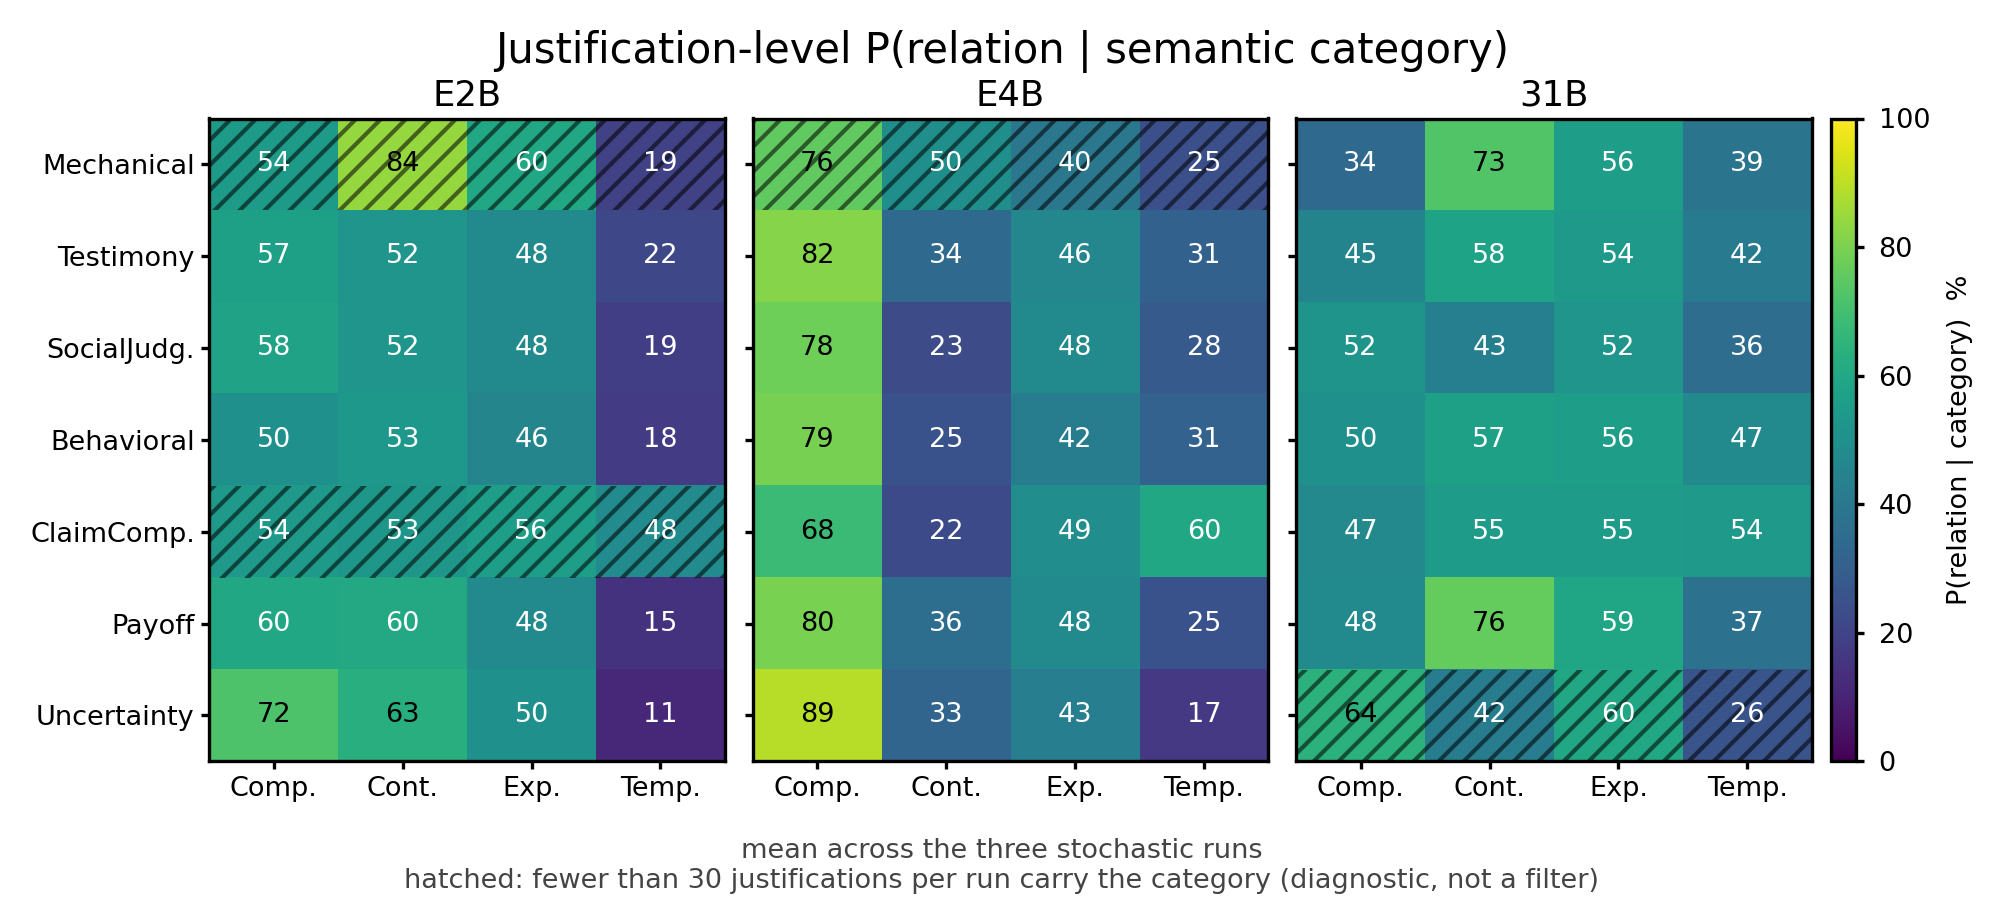

G2_conditional_density.png


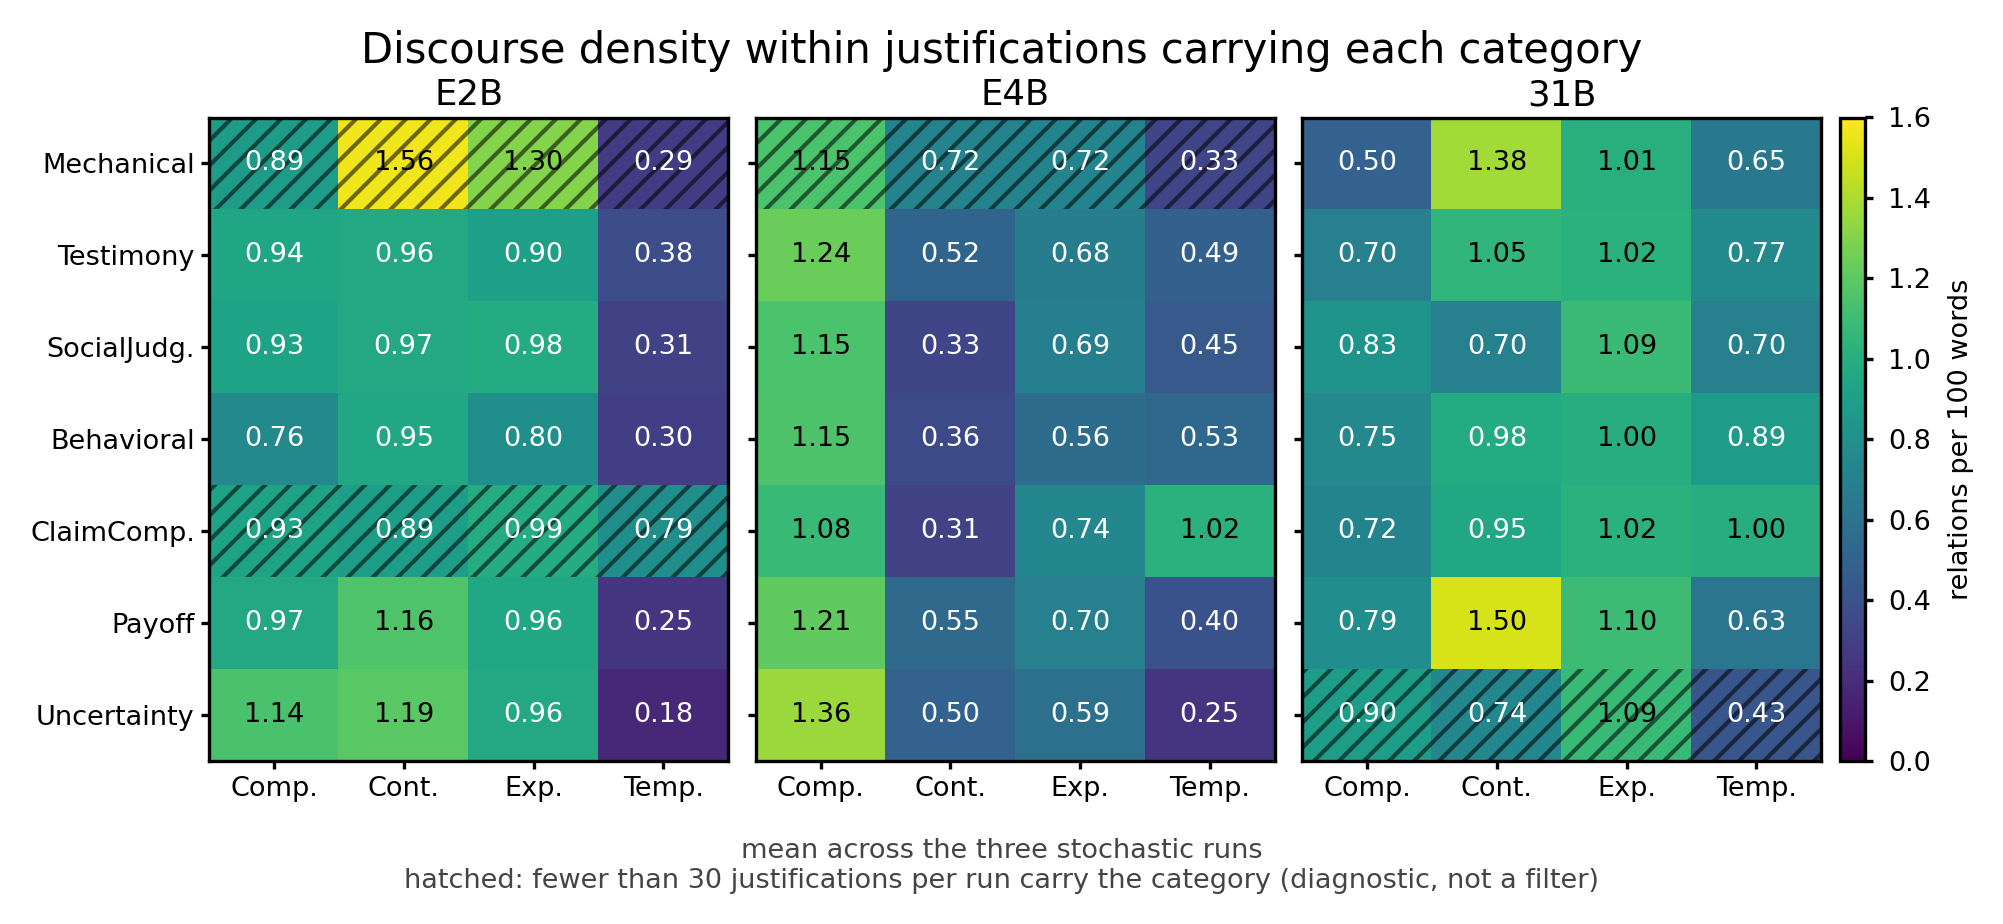

G3_lift.png


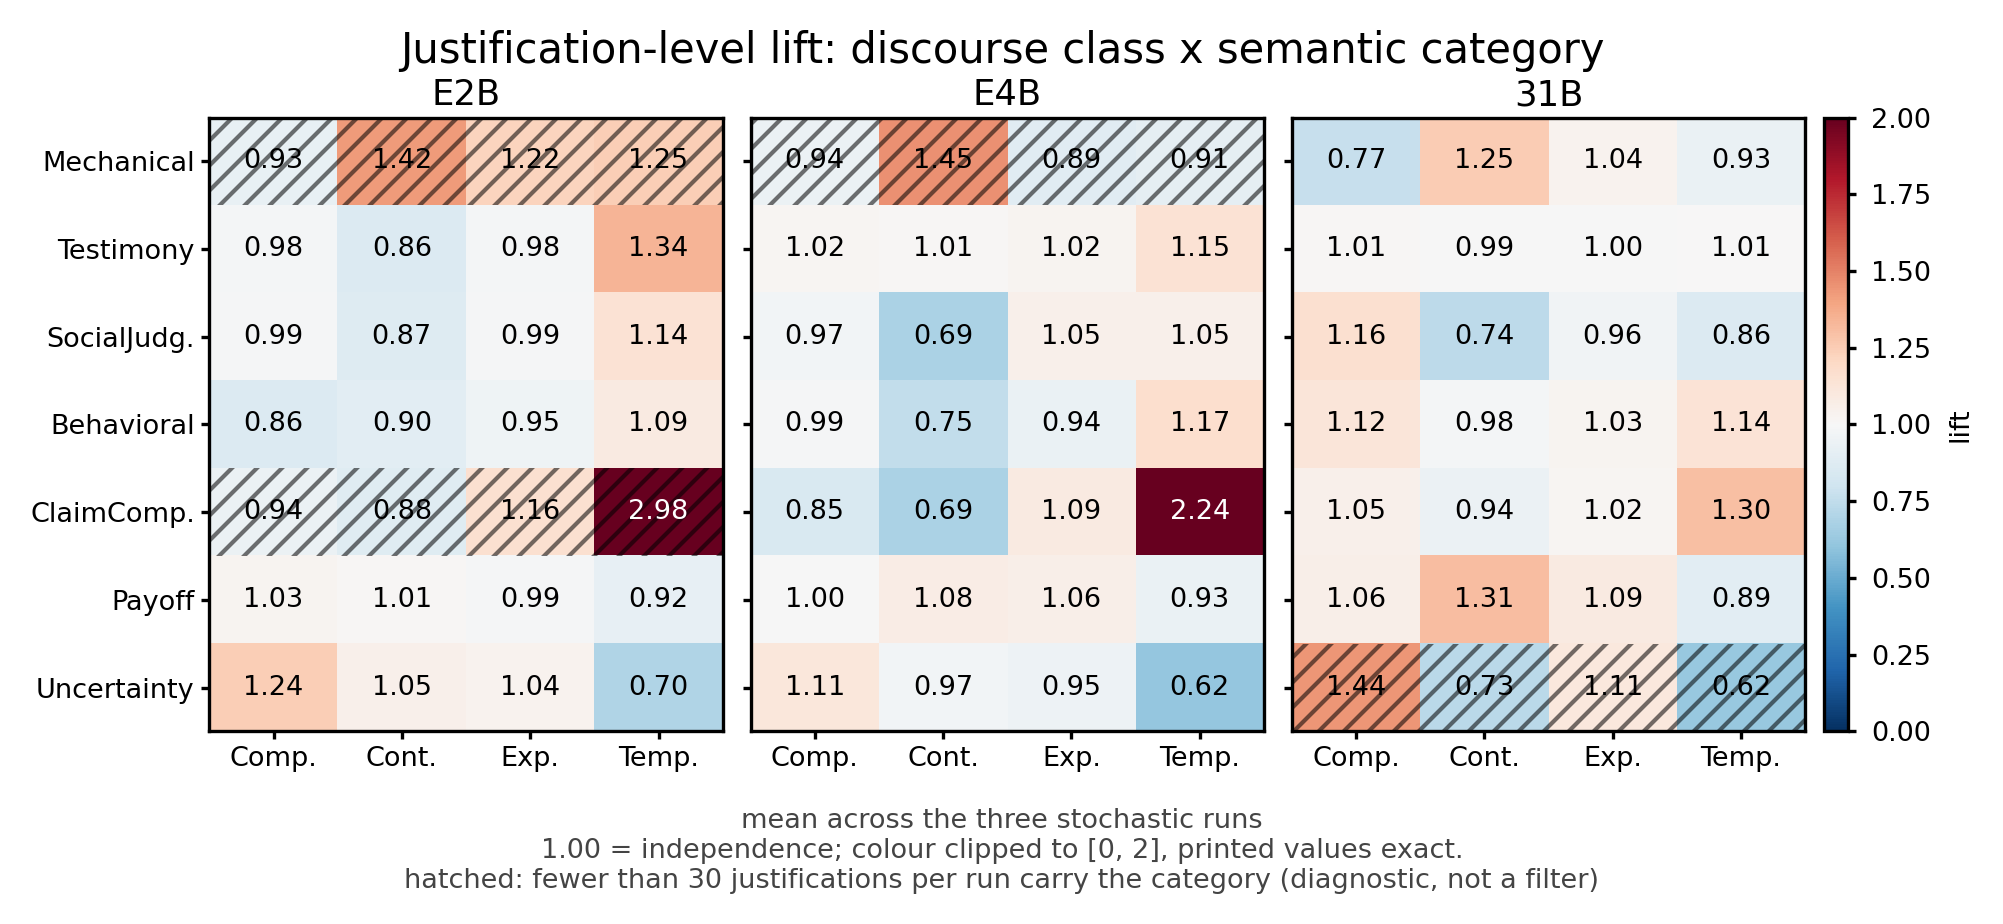

G4_localization.png


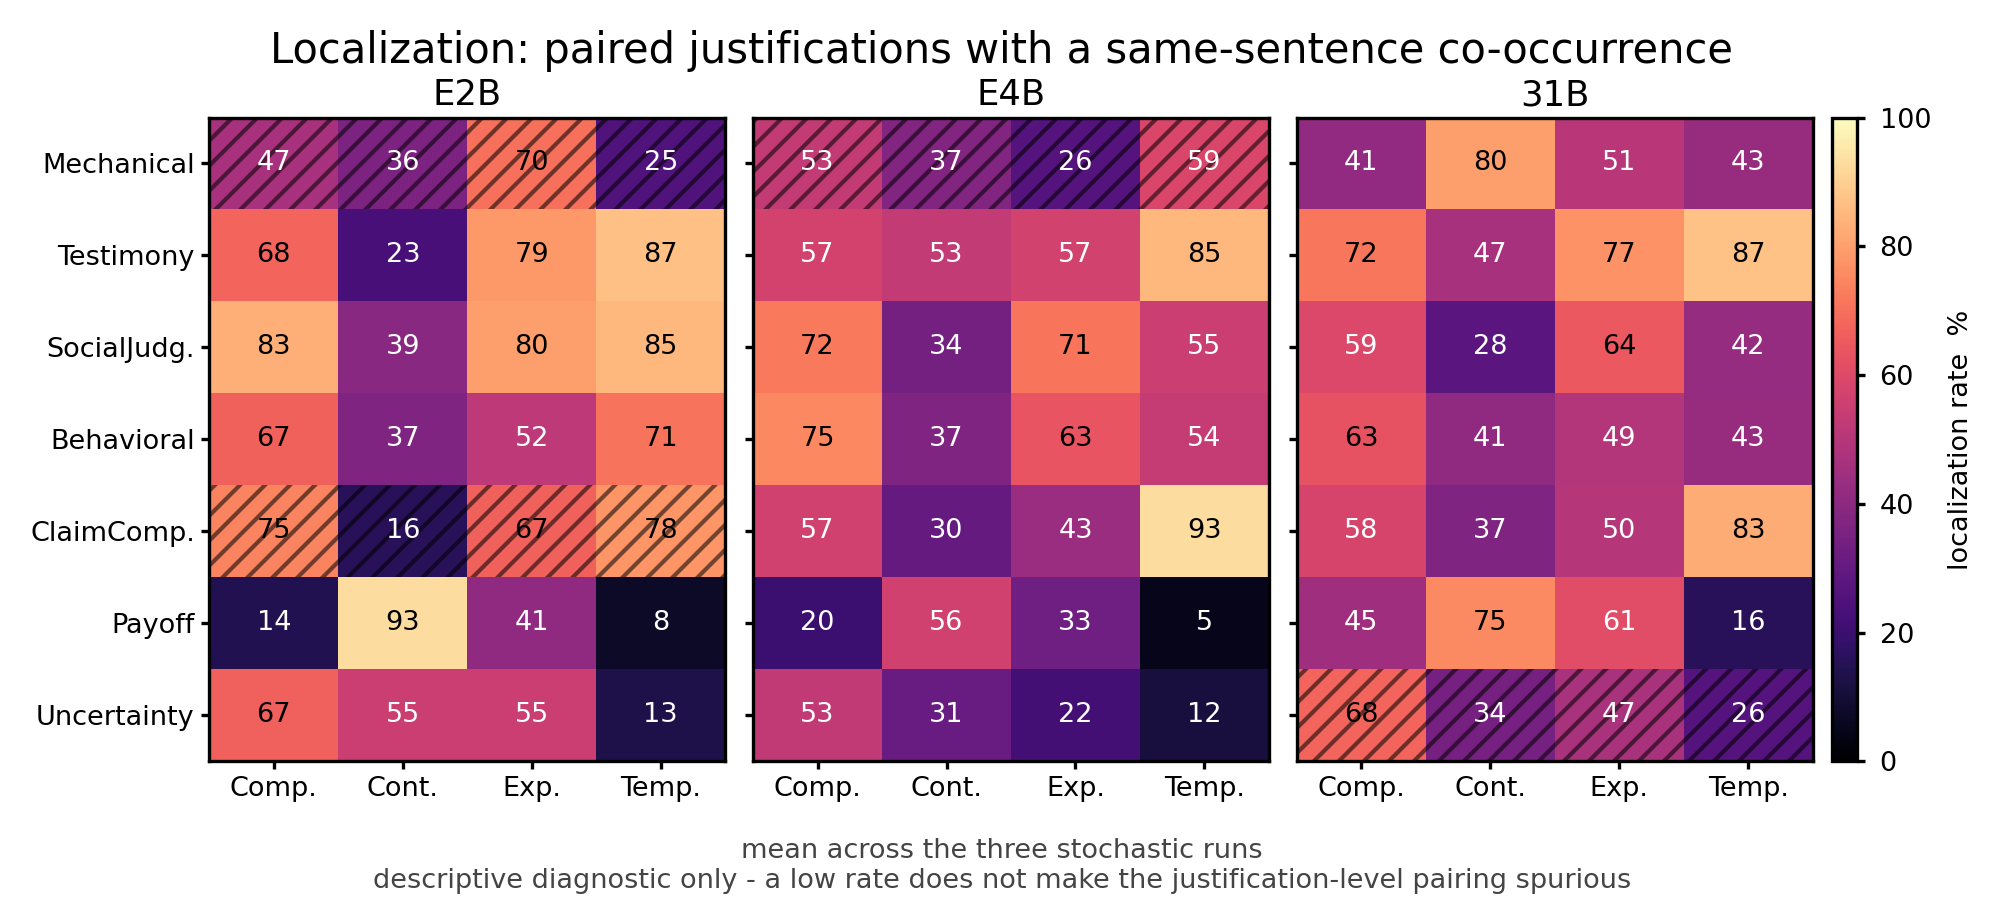

In [15]:
for path in figure_paths:
    if path.name.endswith("_greedy.png"):
        continue
    print(path.name)
    display(Image(filename=str(path)))

### 12.2 Qualitative samples, reselected at justification level

The previous sample was drawn from same-sentence pairings and is superseded.
Selection now requires only that the category and the relation both appear
somewhere in the justification; whether they share a sentence is reported.

In [16]:
samples = kq.build_samples(justifications, sentences_joint, alignment, metadata)
for name, frame in samples.items():
    print("=" * 78)
    print(frame.attrs["label"])
    print(f"  eligible: {frame.attrs['n_eligible']} justifications, "
          f"{frame.attrs['n_eligible_games']} games")
    print(f"  runs: {frame.attrs['run_distribution']}")
    print(f"  sampled {len(frame)} from {frame['game_id'].nunique()} games")
    print(f"  arrangement: {frame['arrangement'].value_counts().to_dict()}")
    display(frame[["game_id", "run_label", "arrangement", "sentence_distance",
                   "category_sentences", "relation_sentences",
                   "semantic_labels_by_sentence"]].head(20))

for path in kq.write_samples(samples, QUALITATIVE):
    print("wrote", path.name)

E2B  Payoff x Contingency (top level)
  eligible: 315 justifications, 169 games
  runs: {'run_3': 112, 'run_2': 105, 'run_1': 98}
  sampled 20 from 20 games
  arrangement: {'same sentence': 18, 'separate sentences': 1, 'adjacent sentences': 1}


,game_id,run_label,arrangement,sentence_distance,category_sentences,relation_sentences,semantic_labels_by_sentence
0,Ego4D / 62c4bc58-3776-4791-ac30-4c9ca5619503 /...,run_1,same sentence,0,4,4,s2:Testimony+SocialJudgment | s3:Uncertainty |...
1,Ego4D / 64076f60-f3fc-4ee6-93e1-3489d8ec7b12 /...,run_3,same sentence,0,3,3,s1:Uncertainty | s2:Testimony+Uncertainty | s3...
2,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#3...,run_1,same sentence,0,3,3,s1:SocialJudgment | s2:Testimony+SocialJudgmen...
3,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#2...,run_3,same sentence,0,3,3,s1:Uncertainty | s2:SocialJudgment | s3:Payoff
4,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#4...,run_3,same sentence,0,3,3,s2:Testimony+ClaimComparison | s3:Payoff | s4:...
5,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#7##Novem...,run_3,same sentence,0,2,2,s1:Testimony | s2:Payoff | s3:Testimony+Uncert...
6,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,run_2,same sentence,0,"2,3",3,s1:Testimony | s2:SocialJudgment+Payoff | s3:P...
7,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,run_3,same sentence,0,3,3,s1:Uncertainty | s2:SocialJudgment+Behavioral ...
8,Ego4D / 1a0d3e22-a6d6-4723-91a0-52fc2c87d5ce /...,run_1,same sentence,0,3,3,s1:SocialJudgment | s2:SocialJudgment | s3:Soc...
9,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#1...,run_1,same sentence,0,3,3,s1:Uncertainty | s2:SocialJudgment+Behavioral ...


31B  Mechanical x Contingency.Condition
  eligible: 128 justifications, 81 games
  runs: {'run_1': 45, 'run_2': 44, 'run_3': 39}
  sampled 20 from 20 games
  arrangement: {'same sentence': 16, 'adjacent sentences': 3, 'separate sentences': 1}


,game_id,run_label,arrangement,sentence_distance,category_sentences,relation_sentences,semantic_labels_by_sentence
0,Youtube / One#Night#Ultimate#Werewolf#533#Even...,run_2,same sentence,0,4,4,s1:Testimony | s2:Testimony | s3:Testimony | s...
1,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#89##Nove...,run_1,same sentence,0,3,3,s1:Testimony | s2:Testimony | s3:Mechanical | ...
2,Ego4D / 1a0d3e22-a6d6-4723-91a0-52fc2c87d5ce /...,run_1,same sentence,0,"1,2,3",2,s1:Mechanical+Behavioral | s2:Mechanical | s3:...
3,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#5...,run_1,same sentence,0,2,2,s1:Testimony | s2:Mechanical | s3:Testimony | ...
4,Ego4D / 3ba069be-60fa-47fc-bd7b-f85bf649a5bd /...,run_2,same sentence,0,3,3,s1:Testimony | s2:Testimony | s3:Mechanical | ...
5,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#4...,run_1,same sentence,0,2,2,s1:Testimony | s2:Mechanical+Testimony | s3:Be...
6,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#86##Nove...,run_2,same sentence,0,"3,4","3,4",s1:Testimony | s2:Testimony | s3:Mechanical | ...
7,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#13##July...,run_2,same sentence,0,4,4,s1:Testimony+Behavioral+ClaimComparison | s2:B...
8,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#4...,run_3,adjacent sentences,1,3,2,s1:Testimony+ClaimComparison | s3:Mechanical+B...
9,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#64##Marc...,run_2,same sentence,0,"3,4",4,s1:Testimony | s2:Testimony | s3:Mechanical | ...


wrote Q2_A_E2B_Payoff_x_Contingency.csv
wrote Q2_B_31B_Mechanical_x_Contingency.Condition.csv


In [17]:
# Lexical diagnostics over the COMPLETE local-realization sets.
for label, model, category, column in (
    ("E2B Payoff + Contingency.Cause", "Gemma 4 2B", "Payoff",
     "sense_Contingency.Cause"),
    ("31B Mechanical + Contingency.Condition", "Gemma 4 31B", "Mechanical",
     "sense_Contingency.Condition"),
):
    local = kq.local_realization_set(sentences_joint, model, category, column)
    diagnostics = kq.lexical_diagnostics(local)
    openings = kq.opening_repetition(local)
    print(f"{label}: {len(local)} locally co-present sentences")
    display(diagnostics.round(1))
    print(f"distinct opening 5-grams: {openings.attrs['n_distinct']} "
          f"over {len(local)}")
    display(openings.head(4).round(1))

E2B Payoff + Contingency.Cause: 284 locally co-present sentences

C:\Users\annab\Documents\GitHub\masters_thesis_sdg\src\justification_analysis\joint_justification\justification_qualitative.py:191: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "n": int(text.str.contains(pattern, regex=True).sum()),
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\src\justification_analysis\joint_justification\justification_qualitative.py:192: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "pct": 100 * float(text.str.contains(pattern, regex=True).mean())}


,diagnostic,n,pct
0,opens with 'Since',276,97.2
1,opens with 'If',0,0.0
2,'Team Village wins/needs',225,79.2
3,'eliminate a werewolf',221,77.8
4,evaluative adjective,135,47.5
5,card-movement verb,4,1.4
6,'center',17,6.0
7,'card',7,2.5
8,modal/state consequent,38,13.4
9,claim-conditional wording,29,10.2


distinct opening 5-grams: 36 over 284


,opening,n,pct
0,since team village wins by,133,46.8
1,since team village needs to,48,16.9
2,since team village wins if,30,10.6
3,since the goal is to,14,4.9


C:\Users\annab\Documents\GitHub\masters_thesis_sdg\src\justification_analysis\joint_justification\justification_qualitative.py:191: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "n": int(text.str.contains(pattern, regex=True).sum()),
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\src\justification_analysis\joint_justification\justification_qualitative.py:192: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "pct": 100 * float(text.str.contains(pattern, regex=True).mean())}


31B Mechanical + Contingency.Condition: 116 locally co-present sentences


,diagnostic,n,pct
0,opens with 'Since',5,4.3
1,opens with 'If',77,66.4
2,'Team Village wins/needs',2,1.7
3,'eliminate a werewolf',0,0.0
4,evaluative adjective,0,0.0
5,card-movement verb,90,77.6
6,'center',25,21.6
7,'card',44,37.9
8,modal/state consequent,63,54.3
9,claim-conditional wording,59,50.9


distinct opening 5-grams: 91 over 116


,opening,n,pct
0,if these claims are true,12,10.3
1,if both these claims are,4,3.4
2,if mike was the werewolf,3,2.6
3,therefore if ashley was the,2,1.7


### 12.3 Final checks

In [18]:
K2 = tables["K2_conditional_prevalence_run_level"]
K5 = tables["K5_bootstrap_prevalence_differences"]
K6 = tables["K6_bootstrap_density_differences"]
K8 = tables["K8_localization_run_level"]   # run level: raw counts live here

checks = [
    ("2,292 justifications", len(justifications) == 2292),
    ("8,044 underlying sentences", len(sentences_joint) == 8044),
    ("11,526 semantic labels", len(layers["semantic"]["labels"]) == 11526),
    ("5,504 accepted relations", len(alignment["aligned"]) == 5504),
    ("169,748 WORD_PATTERN tokens",
     int(justifications["n_words"].sum()) == 169748),
    ("no validation check failed",
     not (tables["K0_validation_report"]["status"] == "FAIL").any()),
    ("toy example passes",
     not (tables["K0b_toy_example_check"]["status"] == "FAIL").any()),
    ("N(c,r) never exceeds N(c)",
     bool((K2["n_justifications_with_both"]
           <= K2["n_justifications_with_category"]).all())),
    ("P(r|c) in [0, 1]",
     bool(K2["conditional_prevalence"].dropna().between(0, 1).all())),
    ("localization rate in [0, 1]",
     bool(K8["localization_rate"].dropna().between(0, 1).all())),
    ("localization numerator never exceeds its denominator",
     bool((K8["n_with_same_sentence"]
           <= K8["n_justifications_with_both"]).all())),
    ("stochastic and greedy never pooled",
     all(set(t["decoding_group"].astype(str)) <= {"Stochastic", "Greedy"}
         for t in tables.values() if "decoding_group" in t.columns)),
    ("both bootstrap CIs bracket their point estimates",
     bool(((K5["ci_low"] <= K5["difference"])
           & (K5["difference"] <= K5["ci_high"])).all())
     and bool(((K6["ci_low"] <= K6["difference"])
               & (K6["difference"] <= K6["ci_high"])).all())),
    ("bootstraps deterministic under the fixed seed",
     kj.prevalence_bootstrap(justifications, "top_level")["ci_low"]
     .equals(K5["ci_low"])),
    ("Other excluded from the comparative analysis",
     kj.OTHER_CATEGORY not in set(K2["semantic_category"].astype(str))),
]

for label, ok in checks:
    print(f"  [{'OK  ' if ok else 'FAIL'}] {label}")
assert all(ok for _, ok in checks), "a final check failed"
print()
print("All final checks passed.")

  [OK  ] 2,292 justifications
  [OK  ] 8,044 underlying sentences
  [OK  ] 11,526 semantic labels
  [OK  ] 5,504 accepted relations
  [OK  ] 169,748 WORD_PATTERN tokens
  [OK  ] no validation check failed
  [OK  ] toy example passes
  [OK  ] N(c,r) never exceeds N(c)
  [OK  ] P(r|c) in [0, 1]
  [OK  ] localization rate in [0, 1]
  [OK  ] localization numerator never exceeds its denominator
  [OK  ] stochastic and greedy never pooled
  [OK  ] both bootstrap CIs bracket their point estimates
  [OK  ] bootstraps deterministic under the fixed seed
  [OK  ] Other excluded from the comparative analysis

All final checks passed.
